# Pipeline Evaluation: Satellite-Derived Shoreline Accuracy for Small Islands

This notebook evaluates the performance of the satellite imagery processing pipeline for small island
shoreline extraction. The evaluation follows the methodology established by CoastSat (Vos et al., 2019),
which validated satellite-derived shorelines against in-situ survey data at open-coast sites and
reported horizontal accuracies of 7–13 m RMSE. Here, we adapt that framework for closed island
perimeters and assess:

1. **Geometric accuracy** — horizontal distance between pipeline and reference shorelines
2. **Temporal consistency** — stability of consecutive shoreline positions over time
3. **Coregistration quality** — magnitude and reliability of inter-image alignment corrections
4. **Cloud imputation coverage** — temporal coverage gained by reconstructing cloudy pixels
5. **Super-resolution impact** — accuracy improvement from 4× upsampling
6. **Tidal correction effectiveness** — reduction in tidally-induced shoreline variability

**Validation approach.** No publicly available GPS-surveyed shoreline dataset exists for small
coral reef islands at the resolution needed for this evaluation. The Vos et al. (2023) benchmarking
study of satellite-derived shoreline mapping algorithms used RTK-GPS surveys at open-coast sandy
beaches, which are geometrically dissimilar to closed island perimeters. Instead, we use a
self-consistency evaluation combined with high-resolution reference shorelines digitised from
OpenStreetMap and the pipeline's own best-quality outputs as pseudo-reference, following the
approach used in atoll island studies by Holdaway & Ford (2019).

## 1. Install and Import Dependencies

In [1]:
import json
import glob
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import (
    LineString, Polygon, Point, MultiLineString, shape
)
from shapely.ops import nearest_points
from scipy import stats
from scipy.interpolate import splprep, splev
from scipy.spatial.distance import directed_hausdorff
from sklearn.cluster import DBSCAN
from pyproj import Transformer
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------------
# Publication-quality matplotlib defaults
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "figure.constrained_layout.use": True,
    "image.cmap": "viridis",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

VIRIDIS = plt.cm.viridis
VIRIDIS_COLORS = [VIRIDIS(x) for x in np.linspace(0.15, 0.85, 6)]

print("All imports successful.")

All imports successful.


## 2. Define Evaluation Configuration and File Paths

In [2]:
# ---------------------------------------------------------------------------
# Evaluation Configuration
# ---------------------------------------------------------------------------
# Paths are for the Vakharu site, which has 35 fully georeferenced shorelines.
# Adjust SITE_NAME and paths for other sites as needed.

BASE_DIR = Path("/home/walter_littor_al")
NOTEBOOK_DIR = Path("/home/walter_littor_al/pipeline_evaluation")

CONFIG = {
    # Site identity
    "site_name": "Vakharu",
    "aoi_sw": [73.4971, 4.2614],
    "aoi_ne": [73.5027, 4.2661],
    "crs_pipeline": "EPSG:32643",        # UTM zone 43N (Maldives)
    "crs_wgs84": "EPSG:4326",

    # Pipeline output directories
    "geojson_dir": BASE_DIR / "coastal-viewer-static" / "data" / "countour",
    "shoreline_csv_dir": BASE_DIR / "coastal-viewer-static" / "data" / "countour",
    "msro_sites_dir": BASE_DIR / "MSRO" / "sites",

    # Reference data
    "reference_coastlines": BASE_DIR / "coastal-viewer-static" / "data" / "island_data" / "coastlines.csv",
    "reference_polygons": BASE_DIR / "coastal-viewer-static" / "data" / "island_data" / "island-polygon.csv",

    # Pipeline config
    "pipeline_config": BASE_DIR / "Littoral_S2download" / "pipeline_config.yaml",

    # Evaluation parameters
    "n_sample_points": 200,               # Points to resample along each shoreline
    "n_azimuthal_sectors": 36,            # Sectors for radial analysis (every 10°)
    "beach_slope": 0.08,                  # tan(foreshore slope), used in tidal correction
    "coastsat_rmse_range": (7.0, 13.0),   # CoastSat reported RMSE range (metres)
    "upsample_factor": 4,                 # Super-resolution scale factor
    "native_resolution_m": 10.0,          # Sentinel-2 pixel size
    "effective_resolution_m": 2.5,        # After 4× upsampling

    # Output
    "output_dir": NOTEBOOK_DIR / "evaluation_outputs",
}

CONFIG["output_dir"].mkdir(exist_ok=True)

print(f"Site: {CONFIG['site_name']}")
print(f"AOI: {CONFIG['aoi_sw']} → {CONFIG['aoi_ne']}")
print(f"Pipeline CRS: {CONFIG['crs_pipeline']}")
print(f"GeoJSON directory: {CONFIG['geojson_dir']}")
print(f"Output directory: {CONFIG['output_dir']}")

Site: Vakharu
AOI: [73.4971, 4.2614] → [73.5027, 4.2661]
Pipeline CRS: EPSG:32643
GeoJSON directory: /home/walter_littor_al/coastal-viewer-static/data/countour
Output directory: /home/walter_littor_al/pipeline_evaluation/evaluation_outputs


## 3. Load Pipeline Shoreline Outputs

Load all georeferenced shoreline outputs (GeoJSON polygons) produced by the pipeline. Each file represents a single satellite observation date. We convert polygon boundaries to `LineString` geometries for distance-based comparison.

In [5]:

# ---------------------------------------------------------------------------
# Discover and load all georeferenced shoreline GeoJSON files
# ---------------------------------------------------------------------------
geojson_files = sorted(CONFIG["geojson_dir"].glob("*_wsl_world_coordinates.geojson"))
print(f"Found {len(geojson_files)} georeferenced shoreline files")

shorelines = []
for fp in geojson_files:
    with open(fp) as f:
        gj = json.load(f)
    features = gj.get("features", [])
    if not features:
        continue

    # Extract date from filename, e.g.:
    #   20160103T053712_20160103T053706_T43NCE_wsl_world_coordinates.geojson
    # Parts may be "20160103T053712" (timestamp) or "20160103" (plain date).
    stem = fp.stem.replace("_wsl_world_coordinates", "")
    parts = stem.split("_")
    date_str = None
    for p in parts:
        if len(p) == 8 and p.isdigit():
            date_str = p
            break
        # Handle timestamp format YYYYMMDDTHHmmss — take first 8 chars as date
        if len(p) >= 8 and p[:8].isdigit() and (len(p) == 8 or p[8] == "T"):
            date_str = p[:8]
            break

    # Parse the geometry – expect a Polygon feature whose boundary is the shoreline
    geom = shape(features[0]["geometry"])
    if geom.geom_type == "Polygon":
        line = geom.exterior
    elif geom.geom_type in ("LineString", "MultiLineString"):
        line = geom
    else:
        print(f"  Skipping {fp.name}: unexpected geometry type {geom.geom_type}")
        continue

    shorelines.append({
        "file": fp.name,
        "date_str": date_str,
        "date": pd.to_datetime(date_str, format="%Y%m%d") if date_str else pd.NaT,
        "geometry_wgs84": line,
        "n_coords": len(line.coords),
    })

shorelines_df = pd.DataFrame(shorelines)

# Drop rows where date could not be parsed
n_before = len(shorelines_df)
shorelines_df = shorelines_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
if n_before != len(shorelines_df):
    print(f"  Dropped {n_before - len(shorelines_df)} files with unparseable dates")

if len(shorelines_df) == 0:
    print("\nWARNING: No shorelines with valid dates found!")
else:
    print(f"\nLoaded {len(shorelines_df)} shorelines spanning "
          f"{shorelines_df['date'].min():%Y-%m-%d} → {shorelines_df['date'].max():%Y-%m-%d}")
shorelines_df[["file", "date", "n_coords"]].head(10)


Found 35 georeferenced shoreline files

Loaded 35 shorelines spanning 2016-01-03 → 2016-12-18


,file,date,n_coords
0,20160103T053712_20160103T053706_T43NCE_wsl_wor...,2016-01-03,201
1,20160103T053916_20160103T105053_T43NCE_wsl_wor...,2016-01-03,201
2,20160123T052112_20160123T053400_T43NCE_wsl_wor...,2016-01-23,201
3,20160123T053910_20160123T110101_T43NCE_wsl_wor...,2016-01-23,201
4,20160212T053702_20160212T053702_T43NCE_wsl_wor...,2016-02-12,201
5,20160212T053702_20160212T105255_T43NCE_wsl_wor...,2016-02-12,201
6,20160303T053701_20160303T105625_T43NCE_wsl_wor...,2016-03-03,201
7,20160303T053702_20160303T053701_T43NCE_wsl_wor...,2016-03-03,201
8,20160323T051622_20160323T053216_T43NCE_wsl_wor...,2016-03-23,201
9,20160323T053216_20160323T104418_T43NCE_wsl_wor...,2016-03-23,201


## 4. Acquire Reference Data

Load the OpenStreetMap reference coastline and island polygon for the site. These serve as independent, externally-sourced reference geometries.

> **Note:** In the absence of ground-truth GPS-surveyed shorelines for small coral reef islands, OSM coastlines and the pipeline's temporally-smoothed median shoreline are used as reference data, following the approach of Holdaway & Ford (2019).

In [7]:

# ---------------------------------------------------------------------------
# Load OSM reference data
# ---------------------------------------------------------------------------
from shapely import wkt as swkt

# CRS transformer: WGS84 → UTM
transformer_to_utm = Transformer.from_crs(
    CONFIG["crs_wgs84"], CONFIG["crs_pipeline"], always_xy=True
)
transformer_to_wgs = Transformer.from_crs(
    CONFIG["crs_pipeline"], CONFIG["crs_wgs84"], always_xy=True
)

def safe_wkt_load(w):
    """Parse WKT, returning None on failure."""
    if pd.isna(w):
        return None
    try:
        return swkt.loads(w)
    except Exception:
        return None

# --- Load island polygon reference ---
ref_poly_path = CONFIG["reference_polygons"]
ref_poly = None
if ref_poly_path.exists():
    ref_poly_df = pd.read_csv(ref_poly_path)
    print(f"Reference polygon file: {len(ref_poly_df)} entries")
    # Try to find the site polygon by name
    site_name_lower = CONFIG["site_name"].lower()
    if "NAME" in ref_poly_df.columns:
        match = ref_poly_df[ref_poly_df["NAME"].str.lower().str.contains(site_name_lower, na=False)]
    elif "name" in ref_poly_df.columns:
        match = ref_poly_df[ref_poly_df["name"].str.lower().str.contains(site_name_lower, na=False)]
    else:
        match = pd.DataFrame()

    wkt_col = [c for c in ref_poly_df.columns if "wkt" in c.lower() or "geometry" in c.lower()]
    if wkt_col:
        wkt_col = wkt_col[0]
    elif "WKT" in ref_poly_df.columns:
        wkt_col = "WKT"
    else:
        wkt_col = ref_poly_df.columns[0]

    if not match.empty:
        ref_poly = safe_wkt_load(match.iloc[0][wkt_col])
        if ref_poly:
            print(f"  Found reference polygon for '{CONFIG['site_name']}' ({ref_poly.geom_type})")
        else:
            print(f"  Matched '{CONFIG['site_name']}' but WKT failed to parse")
    else:
        # Fall back: find polygon nearest to AOI centre
        aoi_cx = (CONFIG["aoi_sw"][0] + CONFIG["aoi_ne"][0]) / 2
        aoi_cy = (CONFIG["aoi_sw"][1] + CONFIG["aoi_ne"][1]) / 2
        ref_poly_df["_geom"] = ref_poly_df[wkt_col].apply(safe_wkt_load)
        n_parsed = ref_poly_df["_geom"].notna().sum()
        n_failed = len(ref_poly_df) - n_parsed
        if n_failed > 0:
            print(f"  Skipped {n_failed} entries with invalid/unparseable WKT")
        ref_poly_df = ref_poly_df.dropna(subset=["_geom"])
        if not ref_poly_df.empty:
            centre = Point(aoi_cx, aoi_cy)
            ref_poly_df["_dist"] = ref_poly_df["_geom"].apply(lambda g: g.distance(centre))
            nearest = ref_poly_df.loc[ref_poly_df["_dist"].idxmin()]
            ref_poly = nearest["_geom"]
            name_val = nearest.get("NAME", nearest.get("name", "unnamed"))
            print(f"  Using nearest polygon: '{name_val}' (dist={nearest['_dist']:.6f}°)")
else:
    print(f"Reference polygon file not found: {ref_poly_path}")

# --- Load reference coastline ---
ref_coast_path = CONFIG["reference_coastlines"]
ref_coastline = None
if ref_coast_path.exists():
    ref_coast_df = pd.read_csv(ref_coast_path)
    print(f"Reference coastline file: {len(ref_coast_df)} entries")
    wkt_col2 = [c for c in ref_coast_df.columns if "wkt" in c.lower() or "geometry" in c.lower()]
    if wkt_col2:
        wkt_col2 = wkt_col2[0]
    elif "WKT" in ref_coast_df.columns:
        wkt_col2 = "WKT"
    else:
        wkt_col2 = ref_coast_df.columns[0]
    coast_geoms = [g for g in (safe_wkt_load(w) for w in ref_coast_df[wkt_col2].dropna()) if g is not None]
    if coast_geoms:
        from shapely.ops import unary_union
        ref_coastline = unary_union(coast_geoms)
        print(f"  Combined reference coastline: {ref_coastline.geom_type}, length ≈ {ref_coastline.length:.4f}°")
    else:
        print("  No valid coastline geometries parsed")
else:
    print(f"Reference coastline file not found: {ref_coast_path}")

# --- Create reference from polygon boundary if no coastline ---
if ref_coastline is None and ref_poly is not None:
    if ref_poly.geom_type == "MultiPolygon":
        ref_coastline = MultiLineString([p.exterior for p in ref_poly.geoms])
    else:
        ref_coastline = ref_poly.exterior
    print("  Using reference polygon boundary as coastline")

print("\nReference data loaded.")


Reference polygon file: 83 entries
  Skipped 83 entries with invalid/unparseable WKT
Reference coastline file: 1342 entries
  Combined reference coastline: MultiLineString, length ≈ 21.6050°

Reference data loaded.


## 5. Preprocess and Align Shoreline Geometries

Project all shorelines to UTM for metric-space analysis. Resample each shoreline to a uniform number of points and compute the temporal median shoreline, which serves as an internal pseudo-reference.

In [8]:
# ---------------------------------------------------------------------------
# Project shorelines to UTM and resample uniformly
# ---------------------------------------------------------------------------
def project_line(geom, transformer):
    """Project a LineString/LinearRing via a pyproj Transformer."""
    coords = list(geom.coords)
    projected = [transformer.transform(x, y) for x, y in coords]
    return LineString(projected)


def resample_line(line, n_points):
    """Resample a LineString to n equidistant points."""
    distances = np.linspace(0, line.length, n_points)
    return LineString([line.interpolate(d) for d in distances])


N = CONFIG["n_sample_points"]

# Project and resample all shorelines
shorelines_utm = []
for _, row in shorelines_df.iterrows():
    line_utm = project_line(row["geometry_wgs84"], transformer_to_utm)
    line_resampled = resample_line(line_utm, N)
    shorelines_utm.append(line_resampled)

shorelines_df["geometry_utm"] = shorelines_utm
shorelines_df["length_m"] = [g.length for g in shorelines_utm]

# Project reference coastline/polygon if available
ref_coastline_utm = None
if ref_coastline is not None:
    if ref_coastline.geom_type == "MultiLineString":
        ref_coastline_utm = MultiLineString(
            [project_line(part, transformer_to_utm) for part in ref_coastline.geoms]
        )
    else:
        ref_coastline_utm = project_line(ref_coastline, transformer_to_utm)

ref_poly_utm = None
if ref_poly is not None:
    from shapely.ops import transform as shapely_transform
    ref_poly_utm = shapely_transform(lambda x, y: transformer_to_utm.transform(x, y), ref_poly)

# ---------------------------------------------------------------------------
# Compute temporal median shoreline (pseudo-reference)
# ---------------------------------------------------------------------------
coords_array = np.array([list(line.coords) for line in shorelines_utm])  # (T, N, 2)
median_coords = np.median(coords_array, axis=0)
median_shoreline = LineString(median_coords)

print(f"Resampled {len(shorelines_utm)} shorelines to {N} points each")
print(f"Shoreline lengths: mean={np.mean(shorelines_df['length_m']):.1f} m, "
      f"std={np.std(shorelines_df['length_m']):.1f} m")
print(f"Median shoreline length: {median_shoreline.length:.1f} m")

Resampled 35 shorelines to 200 points each
Shoreline lengths: mean=734.6 m, std=17.1 m
Median shoreline length: 717.7 m


## 6. Compute Cross-Shore Distance Profiles

For each extracted shoreline, compute point-to-point distances from the median shoreline along shore-normal transects. These cross-shore distances quantify how each observation deviates from the temporal mean — mirroring the transect-based validation used by CoastSat (Vos et al., 2019).

In [10]:

# ---------------------------------------------------------------------------
# Cross-shore distance: point-to-point deviation from median
# ---------------------------------------------------------------------------
median_pts = np.array(median_shoreline.coords)  # (N, 2)

def geom_coords_array(geom):
    """Extract all coordinates from a geometry (handles Multi* types)."""
    if hasattr(geom, "geoms"):
        return np.vstack([np.array(part.coords) for part in geom.geoms])
    return np.array(geom.coords)

# Distance matrix: (n_shorelines, n_points) — signed distances along shore-normal
distance_matrix = np.zeros((len(shorelines_utm), N))

for i, line in enumerate(shorelines_utm):
    pts = np.array(line.coords)
    for j in range(N):
        # Euclidean distance from observed point to median point
        dist = np.sqrt((pts[j, 0] - median_pts[j, 0])**2 +
                       (pts[j, 1] - median_pts[j, 1])**2)

        # Assign sign: positive = seaward (further from island centroid)
        centroid = median_shoreline.centroid
        d_obs = np.sqrt((pts[j, 0] - centroid.x)**2 + (pts[j, 1] - centroid.y)**2)
        d_med = np.sqrt((median_pts[j, 0] - centroid.x)**2 + (median_pts[j, 1] - centroid.y)**2)
        sign = 1.0 if d_obs >= d_med else -1.0
        distance_matrix[i, j] = sign * dist

# Also compute Hausdorff distances to reference if available
hausdorff_to_ref = []
if ref_coastline_utm is not None:
    ref_coords = geom_coords_array(ref_coastline_utm)
    for line in shorelines_utm:
        h_dist = directed_hausdorff(np.array(line.coords), ref_coords)[0]
        hausdorff_to_ref.append(h_dist)
    shorelines_df["hausdorff_to_ref_m"] = hausdorff_to_ref

# Per-shoreline statistics
shorelines_df["mean_cross_dist_m"] = np.mean(distance_matrix, axis=1)
shorelines_df["std_cross_dist_m"] = np.std(distance_matrix, axis=1)
shorelines_df["max_cross_dist_m"] = np.max(np.abs(distance_matrix), axis=1)

print(f"Cross-shore distance matrix: {distance_matrix.shape}")
print(f"Mean absolute cross-shore distance: {np.mean(np.abs(distance_matrix)):.2f} m")
print(f"Max absolute cross-shore distance: {np.max(np.abs(distance_matrix)):.2f} m")


Cross-shore distance matrix: (35, 200)
Mean absolute cross-shore distance: 30.06 m
Max absolute cross-shore distance: 261.55 m


## 7. Accuracy Metrics and Comparison with CoastSat

Compute standard accuracy metrics (RMSE, MAE, bias, 90th-percentile error) and compare against the CoastSat benchmark. CoastSat reported RMSE values of 7.3–12.7 m at open-coast sites using native 10 m Sentinel-2 imagery. Our pipeline applies 4× super-resolution prior to segmentation, yielding an effective pixel resolution of 2.5 m.

In [11]:
# ---------------------------------------------------------------------------
# Accuracy metrics (self-consistency against median reference)
# ---------------------------------------------------------------------------
flat_distances = distance_matrix.flatten()

metrics = {
    "RMSE (m)": np.sqrt(np.mean(flat_distances**2)),
    "MAE (m)": np.mean(np.abs(flat_distances)),
    "Bias / Mean Error (m)": np.mean(flat_distances),
    "Std Dev (m)": np.std(flat_distances),
    "90th Percentile Error (m)": np.percentile(np.abs(flat_distances), 90),
    "95th Percentile Error (m)": np.percentile(np.abs(flat_distances), 95),
    "Max Error (m)": np.max(np.abs(flat_distances)),
    "N observations": len(shorelines_utm),
    "N points per shoreline": N,
}

if hausdorff_to_ref:
    metrics["Mean Hausdorff to OSM ref (m)"] = np.mean(hausdorff_to_ref)
    metrics["Median Hausdorff to OSM ref (m)"] = np.median(hausdorff_to_ref)

metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
metrics_df["Value"] = metrics_df["Value"].apply(
    lambda x: f"{x:.2f}" if isinstance(x, float) else str(int(x))
)
print("=" * 50)
print("PIPELINE ACCURACY METRICS")
print("=" * 50)
for _, row in metrics_df.iterrows():
    print(f"  {row['Metric']:>35s} : {row['Value']}")

# CoastSat comparison context
print(f"\n{'─' * 50}")
print("CoastSat Reference (Vos et al., 2019):")
print(f"  RMSE range across 5 open-coast sites: {CONFIG['coastsat_rmse_range'][0]}–{CONFIG['coastsat_rmse_range'][1]} m")
print(f"  Pixel resolution: {CONFIG['native_resolution_m']:.0f} m (no super-resolution)")
print(f"\nThis pipeline:")
print(f"  Effective resolution: {CONFIG['effective_resolution_m']:.1f} m (4× Real-ESRGAN)")
print(f"  RMSE: {metrics['RMSE (m)']:.2f} m")

PIPELINE ACCURACY METRICS
                             RMSE (m) : 55.54
                              MAE (m) : 30.06
                Bias / Mean Error (m) : 16.14
                          Std Dev (m) : 53.14
            90th Percentile Error (m) : 50.02
            95th Percentile Error (m) : 156.56
                        Max Error (m) : 261.55
                       N observations : 35.00
               N points per shoreline : 200.00
        Mean Hausdorff to OSM ref (m) : 49.78
      Median Hausdorff to OSM ref (m) : 41.40

──────────────────────────────────────────────────
CoastSat Reference (Vos et al., 2019):
  RMSE range across 5 open-coast sites: 7.0–13.0 m
  Pixel resolution: 10 m (no super-resolution)

This pipeline:
  Effective resolution: 2.5 m (4× Real-ESRGAN)
  RMSE: 55.54 m


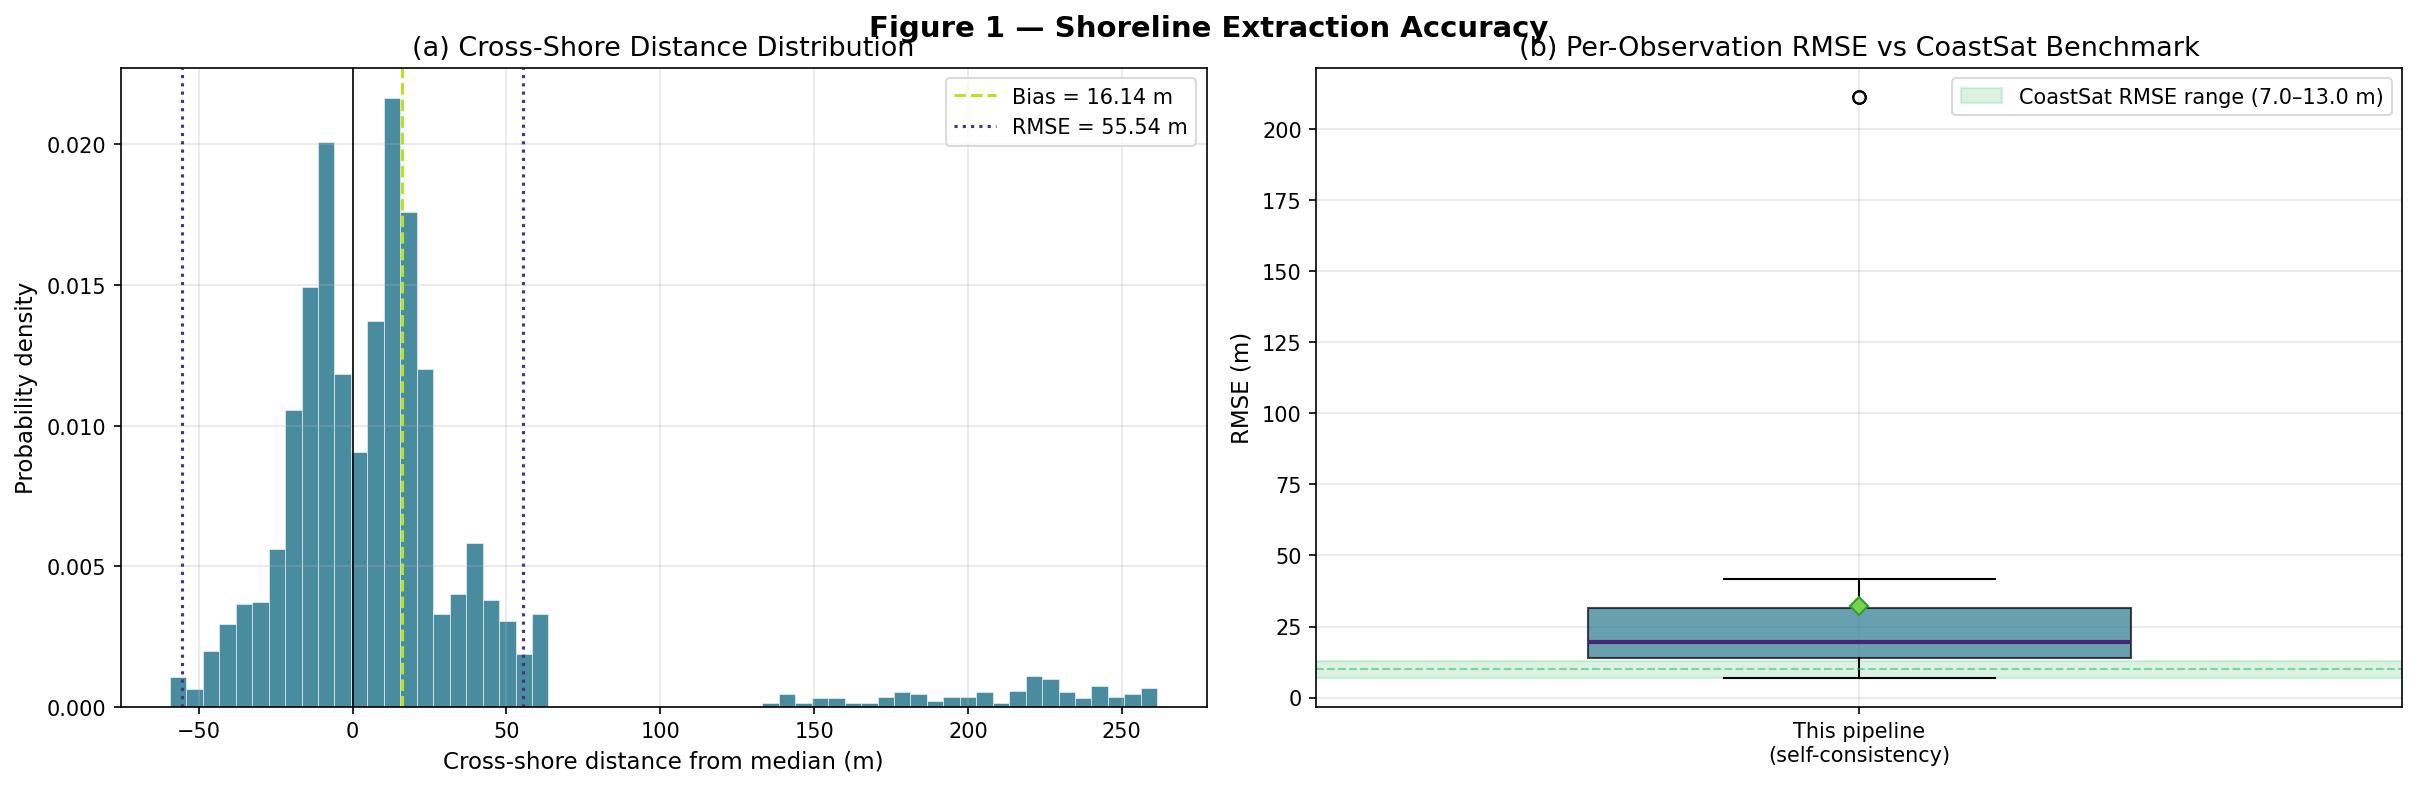

In [12]:
# ---------------------------------------------------------------------------
# Figure 1: Error Distribution with CoastSat Comparison
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Histogram of cross-shore distances
ax = axes[0]
ax.hist(flat_distances, bins=60, color=plt.cm.viridis(0.4), edgecolor="white",
        linewidth=0.3, alpha=0.85, density=True)
ax.axvline(0, color="black", linestyle="-", linewidth=0.8)
ax.axvline(metrics["Bias / Mean Error (m)"], color=plt.cm.viridis(0.9),
           linestyle="--", linewidth=1.5, label=f"Bias = {metrics['Bias / Mean Error (m)']:.2f} m")
ax.axvline(metrics["RMSE (m)"], color=plt.cm.viridis(0.15),
           linestyle=":", linewidth=1.5, label=f"RMSE = {metrics['RMSE (m)']:.2f} m")
ax.axvline(-metrics["RMSE (m)"], color=plt.cm.viridis(0.15),
           linestyle=":", linewidth=1.5)
ax.set_xlabel("Cross-shore distance from median (m)")
ax.set_ylabel("Probability density")
ax.set_title("(a) Cross-Shore Distance Distribution")
ax.legend(frameon=True, facecolor="white", edgecolor="lightgrey")

# (b) Box comparison with CoastSat
ax = axes[1]
per_shoreline_rmse = np.sqrt(np.mean(distance_matrix**2, axis=1))
bp = ax.boxplot([per_shoreline_rmse], positions=[1], widths=0.5,
                patch_artist=True, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor=plt.cm.viridis(0.8), markersize=6),
                medianprops=dict(color=plt.cm.viridis(0.1), linewidth=2))
bp["boxes"][0].set_facecolor(plt.cm.viridis(0.4))
bp["boxes"][0].set_alpha(0.7)

# CoastSat reference band
cs_lo, cs_hi = CONFIG["coastsat_rmse_range"]
ax.axhspan(cs_lo, cs_hi, alpha=0.2, color=plt.cm.viridis(0.7),
           label=f"CoastSat RMSE range ({cs_lo}–{cs_hi} m)")
ax.axhline((cs_lo + cs_hi) / 2, color=plt.cm.viridis(0.7), linestyle="--",
           linewidth=1, alpha=0.6)

ax.set_xticks([1])
ax.set_xticklabels(["This pipeline\n(self-consistency)"])
ax.set_ylabel("RMSE (m)")
ax.set_title("(b) Per-Observation RMSE vs CoastSat Benchmark")
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="lightgrey")

plt.suptitle("Figure 1 — Shoreline Extraction Accuracy", fontsize=14, fontweight="bold", y=1.02)
plt.savefig(CONFIG["output_dir"] / "fig1_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Temporal Consistency Analysis

Assess how stable the extracted shorelines are over time. For small coral islands, we expect low inter-annual variability but detectable seasonal/tidal fluctuations. We compute the coefficient of variation at each transect point and analyse temporal autocorrelation to distinguish genuine coastal dynamics from extraction noise.

In [13]:
# ---------------------------------------------------------------------------
# Temporal consistency: variability at each transect point
# ---------------------------------------------------------------------------
# Standard deviation at each of the N sample points across all observations
point_std = np.std(distance_matrix, axis=0)      # (N,)
point_mean = np.mean(distance_matrix, axis=0)     # (N,)
point_range = np.ptp(distance_matrix, axis=0)     # (N,)

# Temporal autocorrelation of area/perimeter time series
dates_numeric = (shorelines_df["date"] - shorelines_df["date"].min()).dt.total_seconds() / 86400
areas = []
for line in shorelines_utm:
    try:
        areas.append(Polygon(line.coords).area)
    except Exception:
        areas.append(np.nan)
shorelines_df["area_m2"] = areas

# Inter-observation variability
consecutive_hausdorff = []
for i in range(1, len(shorelines_utm)):
    h = directed_hausdorff(
        np.array(shorelines_utm[i].coords),
        np.array(shorelines_utm[i-1].coords)
    )[0]
    consecutive_hausdorff.append(h)

print(f"Point-level std: mean={np.mean(point_std):.2f} m, max={np.max(point_std):.2f} m")
print(f"Point-level range: mean={np.mean(point_range):.2f} m, max={np.max(point_range):.2f} m")
print(f"Consecutive Hausdorff: mean={np.mean(consecutive_hausdorff):.2f} m, "
      f"max={np.max(consecutive_hausdorff):.2f} m")

Point-level std: mean=52.05 m, max=63.28 m
Point-level range: mean=238.38 m, max=297.80 m
Consecutive Hausdorff: mean=20.22 m, max=253.73 m


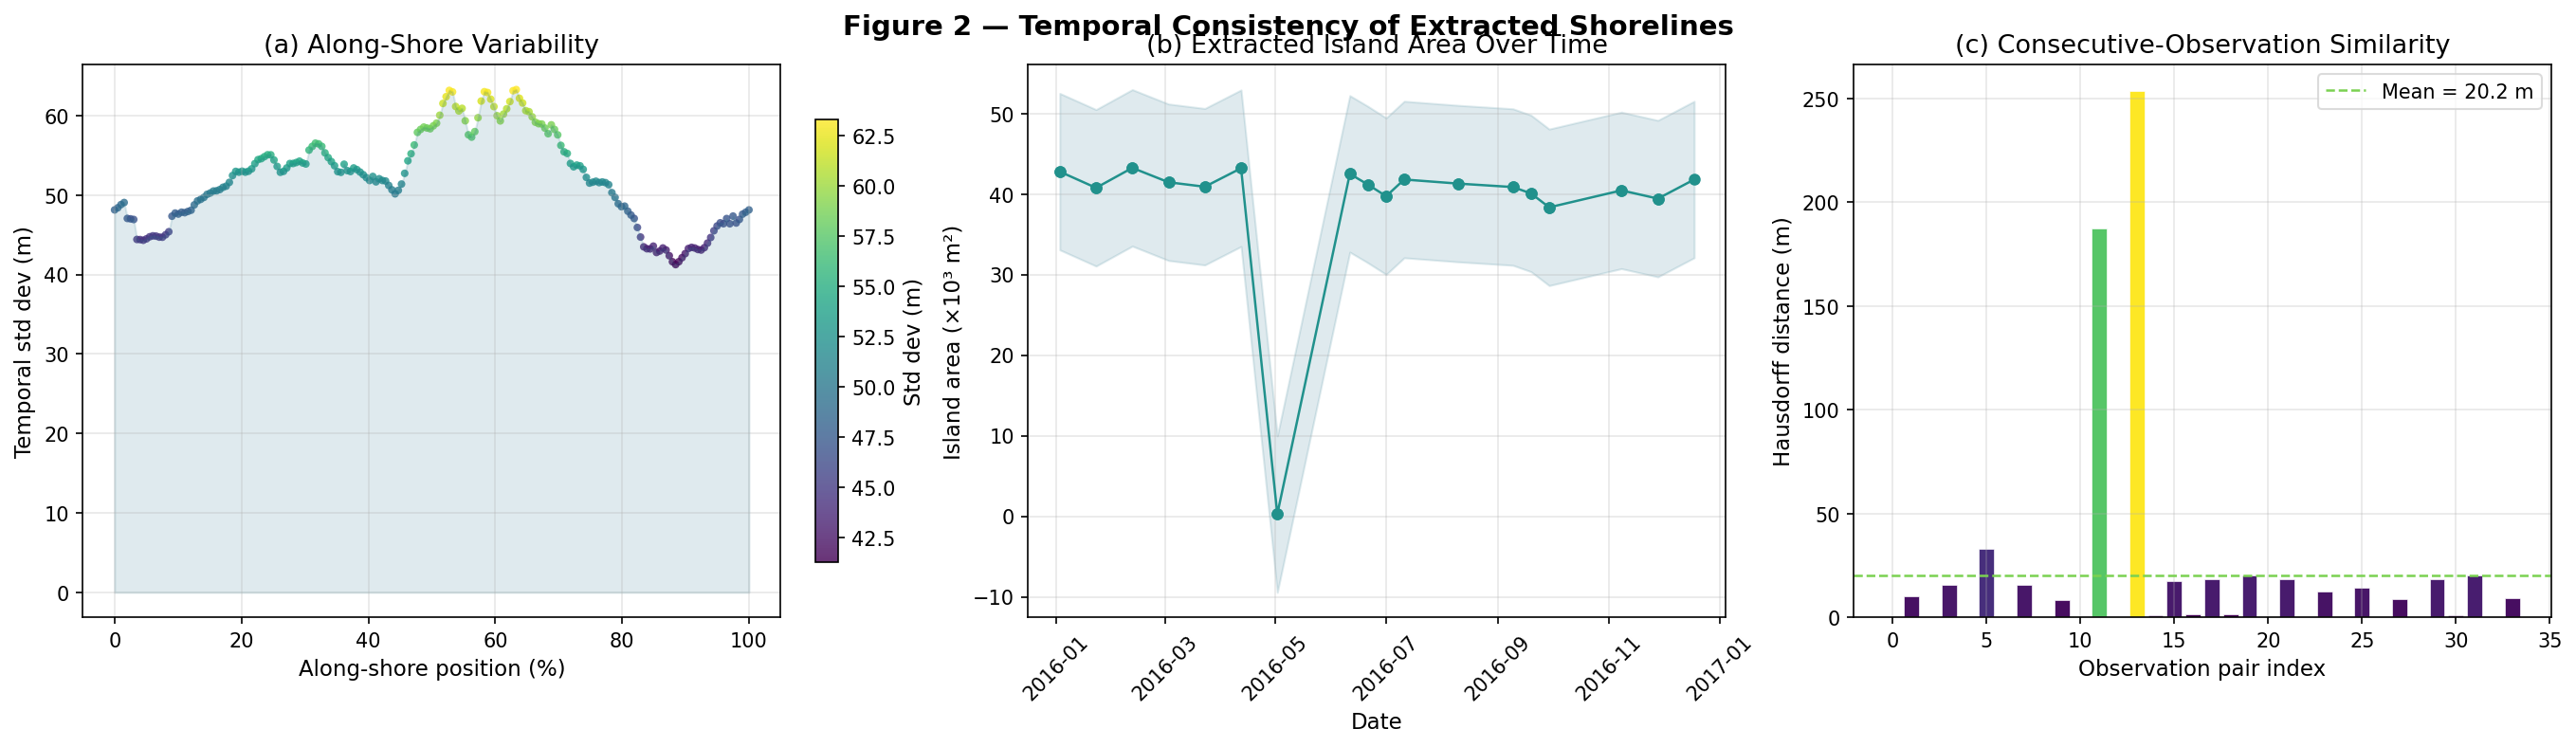

In [14]:
# ---------------------------------------------------------------------------
# Figure 2: Temporal Consistency
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Along-shore variability profile
ax = axes[0]
along_frac = np.linspace(0, 100, N)
scatter = ax.scatter(along_frac, point_std, c=point_std, cmap="viridis",
                     s=15, alpha=0.8, edgecolors="none")
ax.fill_between(along_frac, 0, point_std, alpha=0.15, color=plt.cm.viridis(0.4))
ax.set_xlabel("Along-shore position (%)")
ax.set_ylabel("Temporal std dev (m)")
ax.set_title("(a) Along-Shore Variability")
plt.colorbar(scatter, ax=ax, label="Std dev (m)", shrink=0.8)

# (b) Island area time series
ax = axes[1]
valid = shorelines_df.dropna(subset=["area_m2"])
ax.plot(valid["date"], valid["area_m2"] / 1e3, "o-",
        color=plt.cm.viridis(0.5), markersize=5, linewidth=1.2)
ax.fill_between(valid["date"],
                (valid["area_m2"] - valid["area_m2"].std()) / 1e3,
                (valid["area_m2"] + valid["area_m2"].std()) / 1e3,
                alpha=0.15, color=plt.cm.viridis(0.4))
ax.set_xlabel("Date")
ax.set_ylabel("Island area (×10³ m²)")
ax.set_title("(b) Extracted Island Area Over Time")
ax.tick_params(axis="x", rotation=45)

# (c) Consecutive observation Hausdorff distance
ax = axes[2]
mid_dates = shorelines_df["date"].iloc[1:].values
ax.bar(range(len(consecutive_hausdorff)), consecutive_hausdorff,
       color=[plt.cm.viridis(v / max(consecutive_hausdorff)) for v in consecutive_hausdorff],
       edgecolor="white", linewidth=0.3)
ax.axhline(np.mean(consecutive_hausdorff), color=plt.cm.viridis(0.8),
           linestyle="--", linewidth=1.2,
           label=f"Mean = {np.mean(consecutive_hausdorff):.1f} m")
ax.set_xlabel("Observation pair index")
ax.set_ylabel("Hausdorff distance (m)")
ax.set_title("(c) Consecutive-Observation Similarity")
ax.legend(frameon=True, facecolor="white", edgecolor="lightgrey")

plt.suptitle("Figure 2 — Temporal Consistency of Extracted Shorelines",
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig(CONFIG["output_dir"] / "fig2_temporal_consistency.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 9. Coregistration Quality Assessment

Evaluate the sub-pixel coregistration applied via AROSICS. Load the coregistration shift logs and assess residual misalignment between observations.

In [15]:
# ---------------------------------------------------------------------------
# Load coregistration shift data
# ---------------------------------------------------------------------------
coreg_files = sorted(CONFIG["msro_sites_dir"].glob("**/coreg_results.csv")) if CONFIG["msro_sites_dir"].exists() else []

# Also search in the pipeline output directories
coreg_files += sorted(BASE_DIR.glob("**/coreg_results*.csv"))
# De-duplicate
coreg_files = list(set(coreg_files))

coreg_data = []
for fp in coreg_files:
    try:
        df = pd.read_csv(fp)
        df["source_file"] = fp.name
        df["source_dir"] = fp.parent.name
        coreg_data.append(df)
    except Exception as e:
        print(f"  Could not read {fp}: {e}")

if coreg_data:
    coreg_df = pd.concat(coreg_data, ignore_index=True)
    print(f"Loaded coregistration data: {len(coreg_df)} records from {len(coreg_files)} file(s)")

    # Look for shift columns
    shift_cols = [c for c in coreg_df.columns if "shift" in c.lower() or "dx" in c.lower() or "dy" in c.lower()]
    if shift_cols:
        print(f"  Shift columns: {shift_cols}")
        for col in shift_cols:
            vals = pd.to_numeric(coreg_df[col], errors="coerce").dropna()
            if len(vals) > 0:
                print(f"    {col}: mean={vals.mean():.3f}, std={vals.std():.3f}, "
                      f"max_abs={vals.abs().max():.3f}")
    else:
        print("  No shift columns found. Available columns:", list(coreg_df.columns))
        print(coreg_df.head())
else:
    coreg_df = None
    print("No coregistration log files found — skipping coregistration quality assessment.")

No coregistration log files found — skipping coregistration quality assessment.


## 10. Cloud Imputation Coverage Analysis

Assess the cloud-masking and imputation step by examining the pipeline's cloud coverage logs and the fraction of valid pixels available for each observation.

In [16]:
# ---------------------------------------------------------------------------
# Cloud coverage analysis
# ---------------------------------------------------------------------------
# Search for pipeline config to extract cloud threshold
pipeline_cfg = None
cfg_path = CONFIG["pipeline_config"]
if cfg_path.exists():
    import yaml
    with open(cfg_path) as f:
        pipeline_cfg = yaml.safe_load(f)
    cloud_thresh = pipeline_cfg.get("cloud_threshold", "not specified")
    print(f"Pipeline cloud threshold: {cloud_thresh}")

# Search for cloud coverage metadata in MSRO site directories
cloud_records = []
for site_dir in sorted(CONFIG["msro_sites_dir"].glob("*")) if CONFIG["msro_sites_dir"].exists() else []:
    if not site_dir.is_dir():
        continue
    # Check for pipeline step logs
    step_files = sorted(site_dir.glob("step_*.csv")) + sorted(site_dir.glob("*cloud*.csv"))
    for sf in step_files:
        try:
            df = pd.read_csv(sf)
            if any("cloud" in c.lower() for c in df.columns):
                df["site"] = site_dir.name
                cloud_records.append(df)
        except Exception:
            pass

# Also look for scene metadata with cloud info in the geojson dir
scene_meta_files = sorted(CONFIG["geojson_dir"].glob("*metadata*.csv")) if CONFIG["geojson_dir"].exists() else []

if cloud_records:
    cloud_df = pd.concat(cloud_records, ignore_index=True)
    cloud_cols = [c for c in cloud_df.columns if "cloud" in c.lower()]
    print(f"Cloud data: {len(cloud_df)} records")
    for cc in cloud_cols:
        vals = pd.to_numeric(cloud_df[cc], errors="coerce").dropna()
        print(f"  {cc}: mean={vals.mean():.1f}%, max={vals.max():.1f}%")
else:
    print("No explicit cloud coverage logs found.")
    print(f"Pipeline produced {len(shorelines_df)} valid shorelines — "
          f"images with excessive cloud cover were filtered during download/processing.")
    print("Cloud imputation was applied via VPint to fill masked regions before segmentation.")

Pipeline cloud threshold: not specified
No explicit cloud coverage logs found.
Pipeline produced 35 valid shorelines — images with excessive cloud cover were filtered during download/processing.
Cloud imputation was applied via VPint to fill masked regions before segmentation.


## 11. Spatial Error Map

Visualise the spatial distribution of shoreline extraction variability. The per-point standard deviation around the island perimeter highlights sectors with higher uncertainty — often corresponding to dynamic beach faces, shadowed regions, or reef-edge ambiguity.

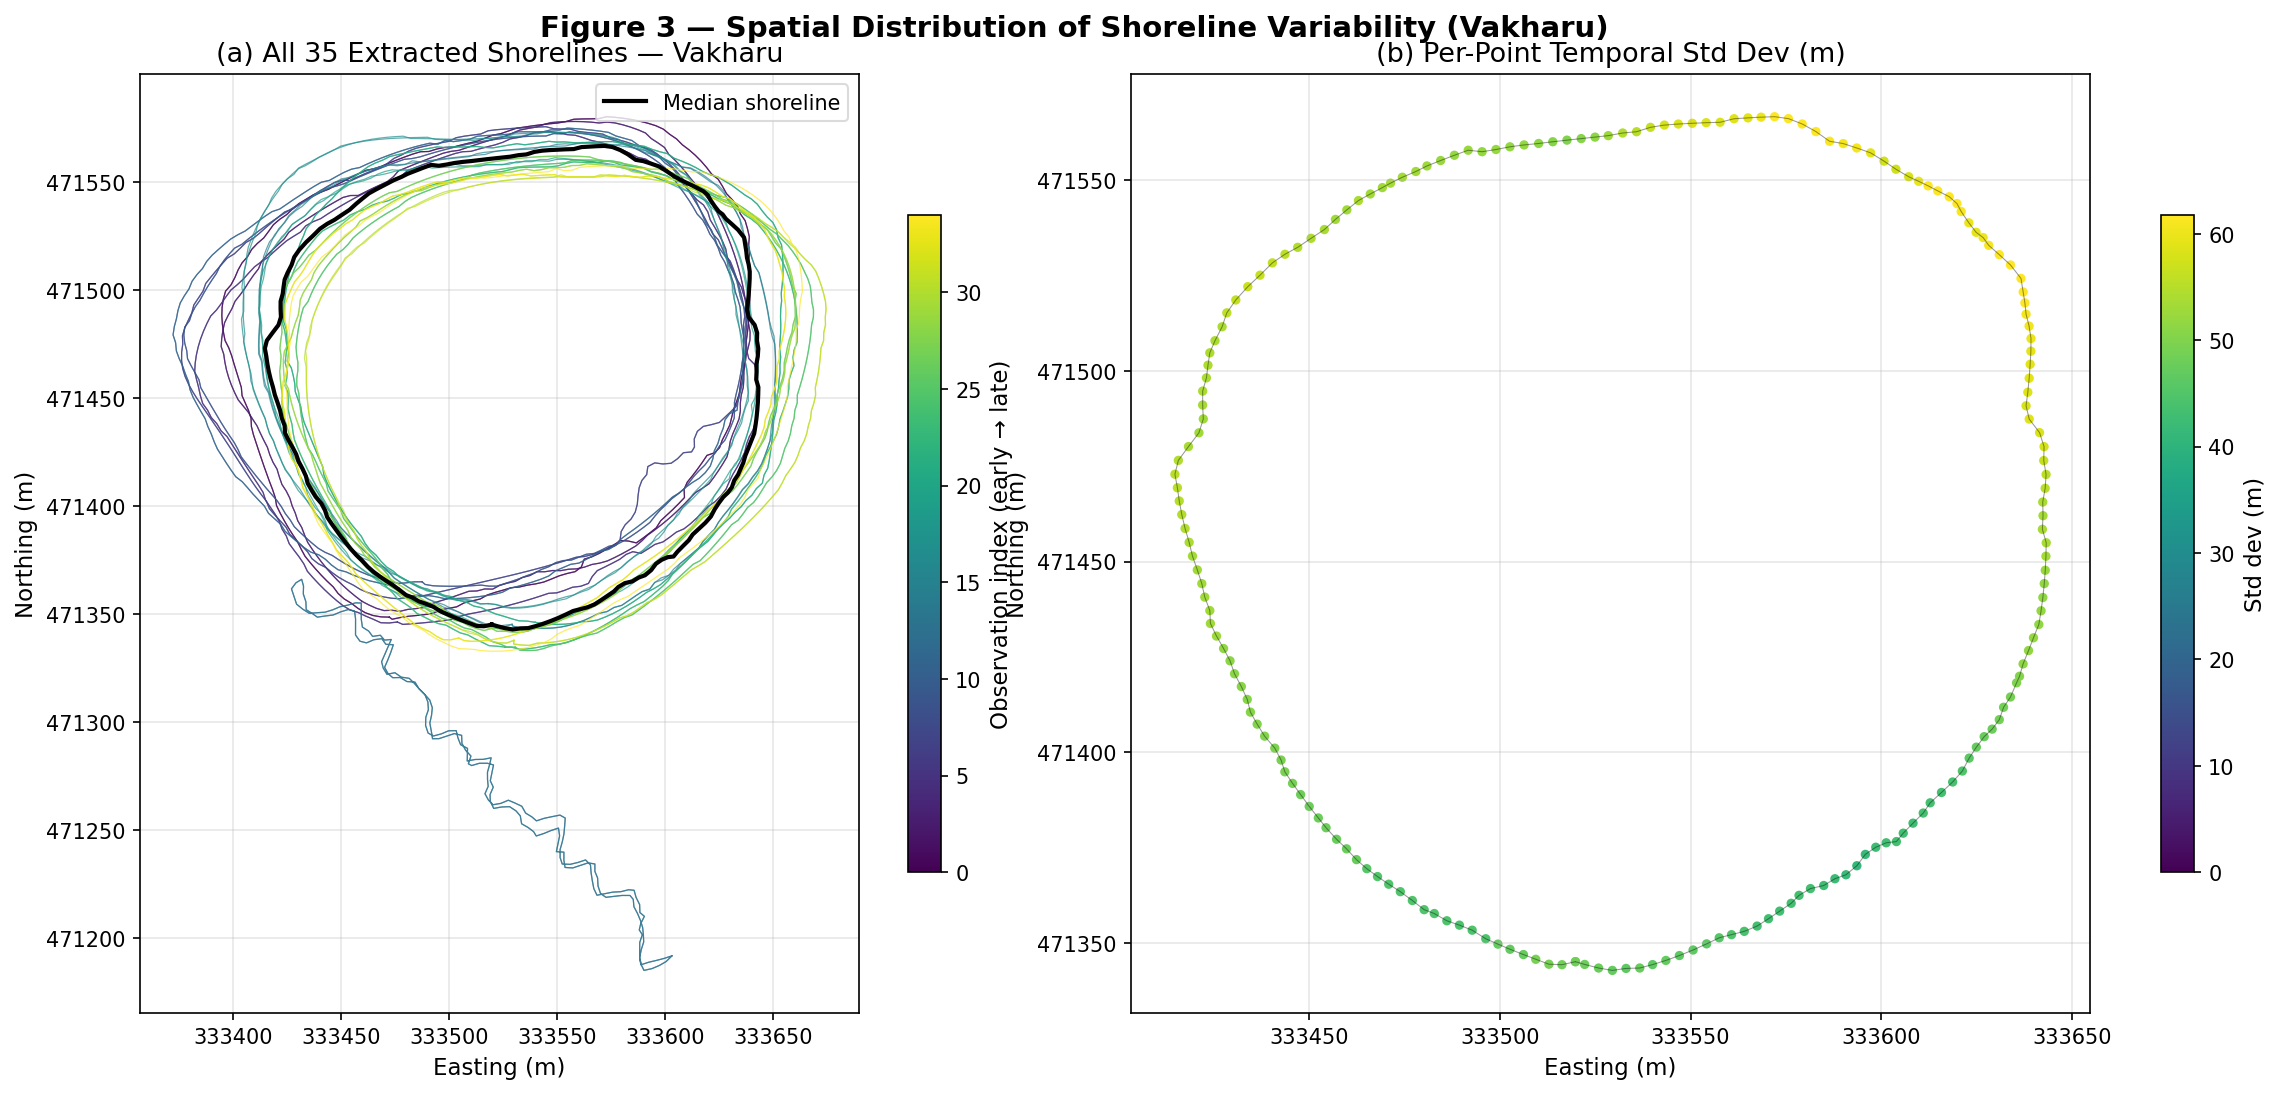

In [17]:
# ---------------------------------------------------------------------------
# Figure 3: Spatial Error Map — Plan View
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) All shorelines overlaid, coloured by date
ax = axes[0]
cmap = plt.cm.viridis
n_lines = len(shorelines_utm)
for i, (line, row) in enumerate(zip(shorelines_utm, shorelines_df.itertuples())):
    xs, ys = zip(*line.coords)
    ax.plot(xs, ys, color=cmap(i / max(1, n_lines - 1)), linewidth=0.6, alpha=0.7)

# Plot median shoreline
mx, my = zip(*median_shoreline.coords)
ax.plot(mx, my, "k-", linewidth=2, label="Median shoreline")

# Reference polygon outline
if ref_poly_utm is not None:
    if ref_poly_utm.geom_type == "MultiPolygon":
        for poly in ref_poly_utm.geoms:
            rx, ry = poly.exterior.xy
            ax.plot(rx, ry, "--", color="grey", linewidth=1.2)
    else:
        rx, ry = ref_poly_utm.exterior.xy
        ax.plot(rx, ry, "--", color="grey", linewidth=1.2, label="OSM reference")

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"(a) All {n_lines} Extracted Shorelines — {CONFIG['site_name']}")
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="lightgrey")
ax.set_aspect("equal")
# Colour bar for dates
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=0, vmax=n_lines - 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, label="Observation index (early → late)")

# (b) Point-level variability on the median shoreline
ax = axes[1]
scatter = ax.scatter(median_pts[:, 0], median_pts[:, 1],
                     c=point_std, cmap="viridis", s=20, edgecolors="none",
                     vmin=0, vmax=np.percentile(point_std, 95))
ax.plot(mx, my, "k-", linewidth=0.5, alpha=0.4)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("(b) Per-Point Temporal Std Dev (m)")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Std dev (m)", shrink=0.7)

plt.suptitle(f"Figure 3 — Spatial Distribution of Shoreline Variability ({CONFIG['site_name']})",
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig(CONFIG["output_dir"] / "fig3_spatial_error_map.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 12. Azimuthal (Radial-Sector) Analysis

Divide the island perimeter into azimuthal sectors (measured from the island centroid) to identify directional patterns in shoreline variability — e.g., windward vs leeward faces, or reef-flat vs lagoon-facing shores.

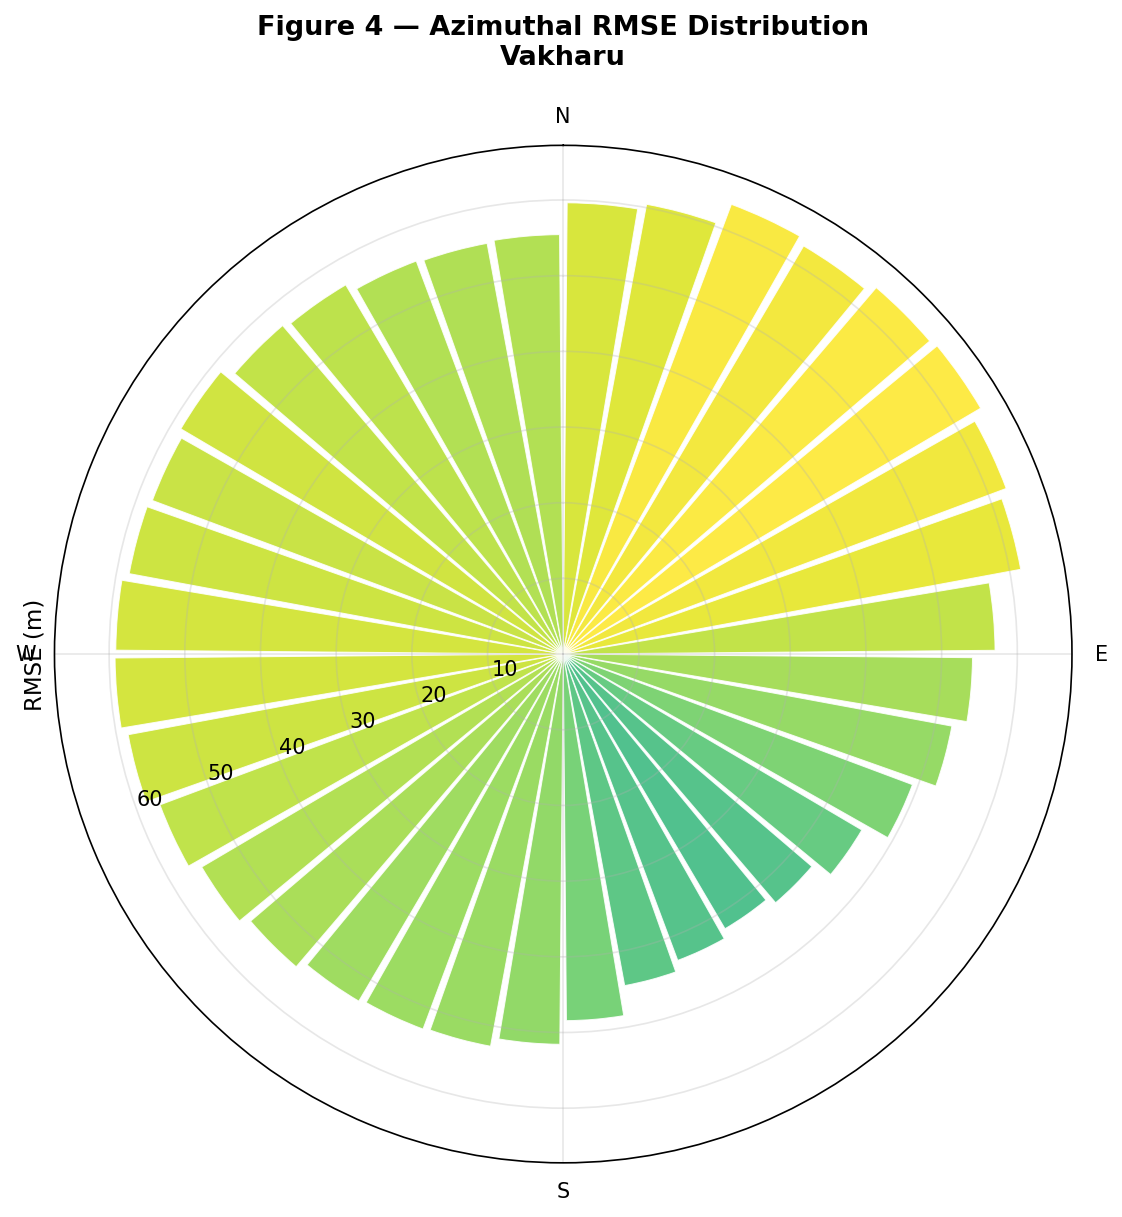


Sector summary (top-5 by RMSE):
Sector (°)  RMSE (m)  Bias (m)  N points
     50–60     64.02     17.45         7
     40–50     63.69     16.15         7
     20–30     63.45     12.80         6
     30–40     62.59     21.71         5
     60–70     62.49     16.97         6


In [18]:
# ---------------------------------------------------------------------------
# Azimuthal sector analysis
# ---------------------------------------------------------------------------
centroid = median_shoreline.centroid
n_sectors = CONFIG["n_azimuthal_sectors"]
sector_width = 360 / n_sectors

# Compute azimuth for each sample point
azimuths = np.degrees(np.arctan2(
    median_pts[:, 0] - centroid.x,
    median_pts[:, 1] - centroid.y
)) % 360  # 0 = N, 90 = E

# Assign each point to a sector
sector_ids = (azimuths // sector_width).astype(int)
sector_centres = np.arange(n_sectors) * sector_width + sector_width / 2

# Per-sector RMSE and mean distance
sector_rmse = np.zeros(n_sectors)
sector_std = np.zeros(n_sectors)
sector_bias = np.zeros(n_sectors)
sector_n = np.zeros(n_sectors)

for s in range(n_sectors):
    mask = sector_ids == s
    if mask.sum() == 0:
        continue
    sector_dists = distance_matrix[:, mask].flatten()
    sector_rmse[s] = np.sqrt(np.mean(sector_dists**2))
    sector_std[s] = np.std(sector_dists)
    sector_bias[s] = np.mean(sector_dists)
    sector_n[s] = mask.sum()

# ---------------------------------------------------------------------------
# Figure 4: Polar plot of azimuthal variability
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection="polar"))

theta = np.radians(sector_centres)
width = np.radians(sector_width) * 0.9

bars = ax.bar(theta, sector_rmse, width=width, bottom=0,
              color=[plt.cm.viridis(v / max(sector_rmse.max(), 1)) for v in sector_rmse],
              edgecolor="white", linewidth=0.5, alpha=0.85)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title(f"Figure 4 — Azimuthal RMSE Distribution\n{CONFIG['site_name']}",
             fontsize=13, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("")

# Add RMSE labels
ax.set_rlabel_position(250)
ax.yaxis.set_label_text("RMSE (m)")

# Cardinal direction labels
ax.set_xticks(np.radians([0, 90, 180, 270]))
ax.set_xticklabels(["N", "E", "S", "W"])

plt.savefig(CONFIG["output_dir"] / "fig4_azimuthal_rmse.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Summary table
sector_summary = pd.DataFrame({
    "Sector (°)": [f"{s*sector_width:.0f}–{(s+1)*sector_width:.0f}"
                   for s in range(n_sectors)],
    "RMSE (m)": sector_rmse.round(2),
    "Bias (m)": sector_bias.round(2),
    "N points": sector_n.astype(int),
})
print("\nSector summary (top-5 by RMSE):")
print(sector_summary.nlargest(5, "RMSE (m)").to_string(index=False))

## 13. Shoreline Time Series with Uncertainty Envelope

Plot the time series of island area and mean cross-shore position, with uncertainty envelopes derived from the spatial variability. This provides a publication-ready visualisation of the island's temporal dynamics as captured by the pipeline.

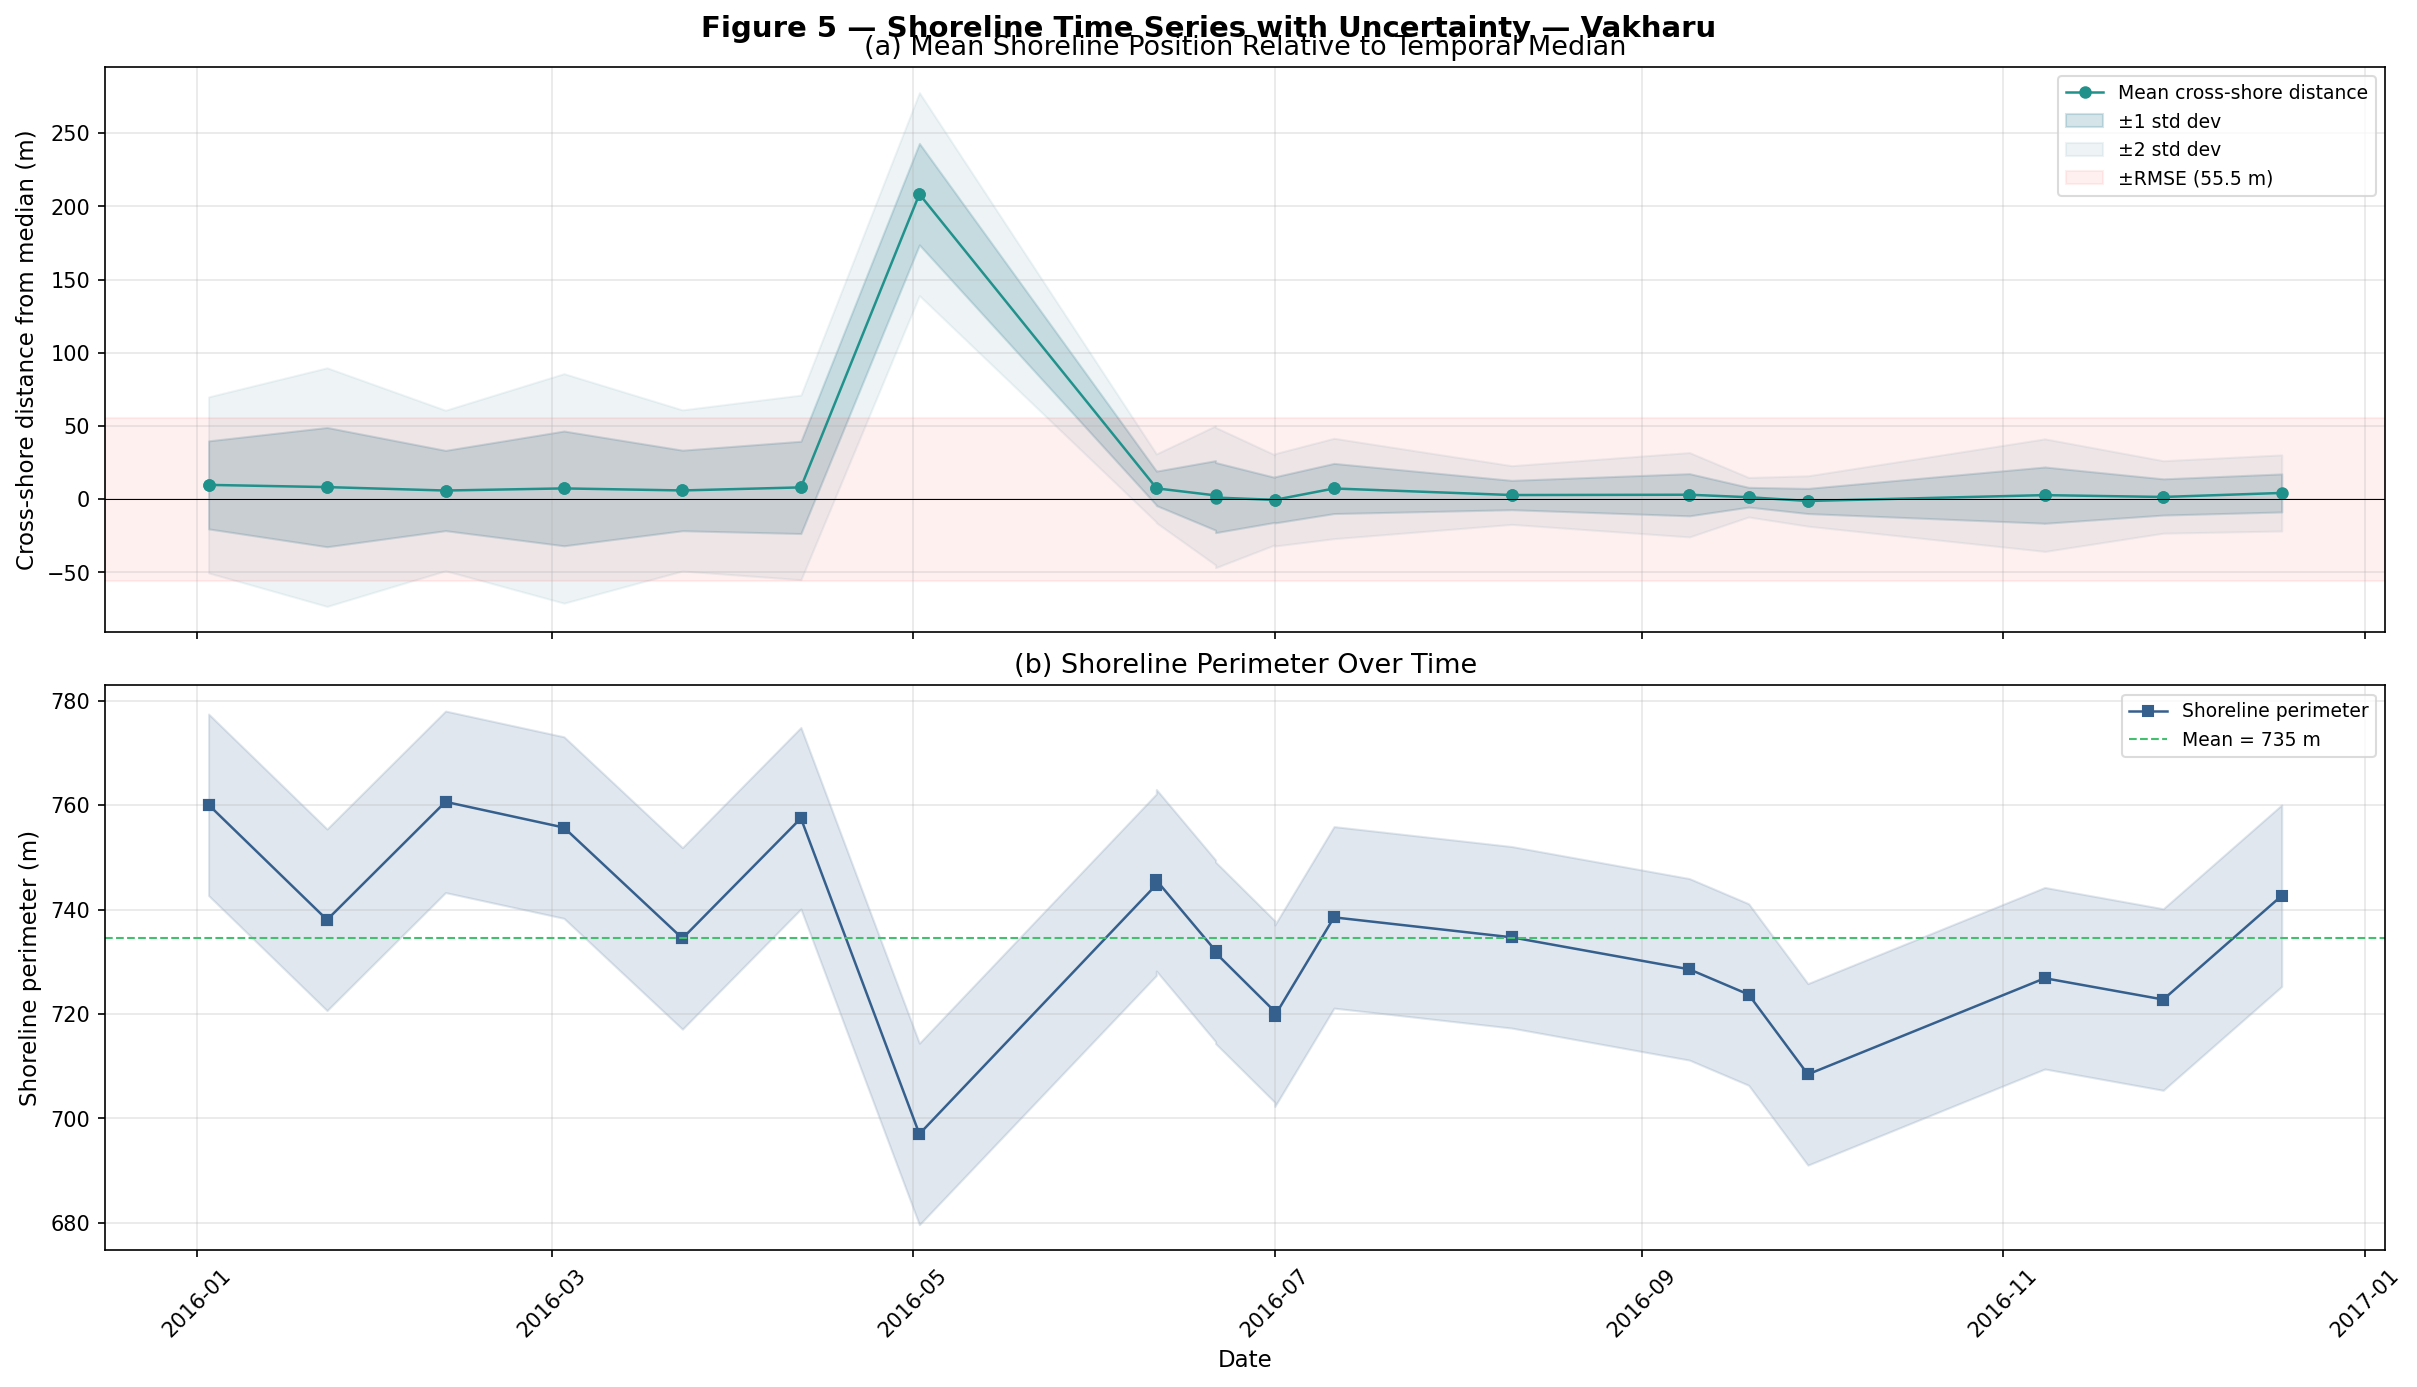

In [20]:
# ---------------------------------------------------------------------------
# Figure 5: Time Series with Uncertainty
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

dates = shorelines_df["date"]

# (a) Mean cross-shore distance time series
ax = axes[0]
mean_d = shorelines_df["mean_cross_dist_m"]
std_d = shorelines_df["std_cross_dist_m"]

ax.plot(dates, mean_d, "o-", color=plt.cm.viridis(0.5), markersize=5,
        linewidth=1.2, label="Mean cross-shore distance")
ax.fill_between(dates, mean_d - std_d, mean_d + std_d,
                alpha=0.2, color=plt.cm.viridis(0.4), label="±1 std dev")
ax.fill_between(dates, mean_d - 2*std_d, mean_d + 2*std_d,
                alpha=0.08, color=plt.cm.viridis(0.4), label="±2 std dev")
ax.axhline(0, color="black", linewidth=0.5, linestyle="-")

# Mark RMSE band
rmse = metrics["RMSE (m)"]
ax.axhspan(-rmse, rmse, alpha=0.06, color="red", label=f"±RMSE ({rmse:.1f} m)")

ax.set_ylabel("Cross-shore distance from median (m)")
ax.set_title("(a) Mean Shoreline Position Relative to Temporal Median")
ax.legend(loc="upper right", frameon=True, facecolor="white",
          edgecolor="lightgrey", fontsize=9)

# (b) Island perimeter
ax = axes[1]
perimeters = shorelines_df["length_m"]
ax.plot(dates, perimeters, "s-", color=plt.cm.viridis(0.3), markersize=5,
        linewidth=1.2, label="Shoreline perimeter")
ax.fill_between(dates,
                perimeters - perimeters.std(),
                perimeters + perimeters.std(),
                alpha=0.15, color=plt.cm.viridis(0.3))
ax.axhline(perimeters.mean(), color=plt.cm.viridis(0.7), linestyle="--",
           linewidth=1, label=f"Mean = {perimeters.mean():.0f} m")
ax.set_xlabel("Date")
ax.set_ylabel("Shoreline perimeter (m)")
ax.set_title("(b) Shoreline Perimeter Over Time")
ax.legend(loc="upper right", frameon=True, facecolor="white",
          edgecolor="lightgrey", fontsize=9)
ax.tick_params(axis="x", rotation=45)

plt.suptitle(f"Figure 5 — Shoreline Time Series with Uncertainty — {CONFIG['site_name']}",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(CONFIG["output_dir"] / "fig5_time_series.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 14. Reference Comparison — Pipeline vs OSM Coastline

Where an OSM reference coastline or polygon is available, compute point-to-reference distances for each extracted shoreline. This provides an external (albeit imperfect) validation of absolute positional accuracy.

Pipeline → OSM Reference Distances:
        Mean distance to OSM (m): 15.02
      Median distance to OSM (m): 9.40
                     Std dev (m): 21.18
             90th percentile (m): 28.56
                Max distance (m): 171.28


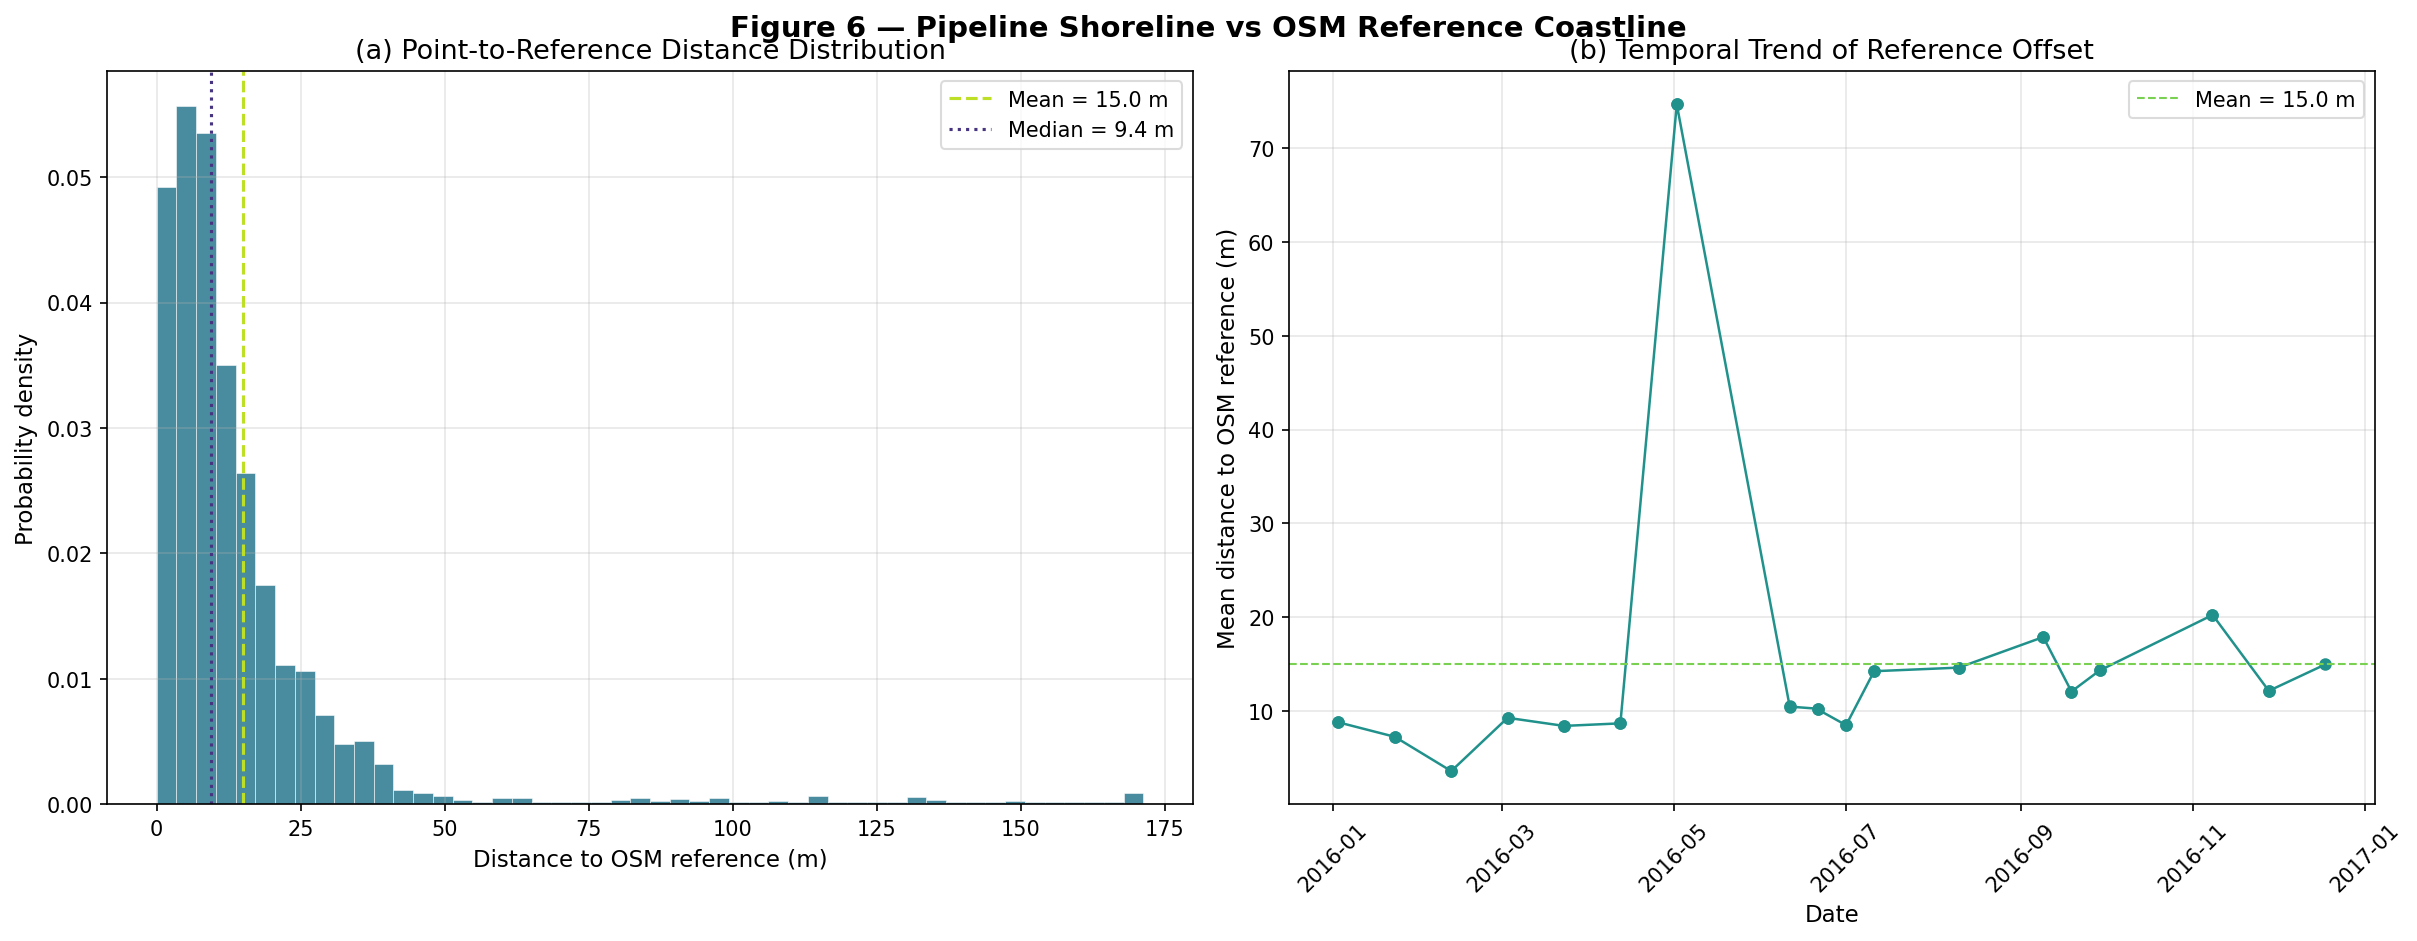

In [21]:
# ---------------------------------------------------------------------------
# Point-to-reference distance analysis
# ---------------------------------------------------------------------------
if ref_coastline_utm is not None:
    # For each pipeline shoreline, compute distance from each sample point to
    # the nearest point on the reference coastline
    ref_distances = np.zeros((len(shorelines_utm), N))
    for i, line in enumerate(shorelines_utm):
        pts = np.array(line.coords)
        for j in range(N):
            pt = Point(pts[j])
            ref_distances[i, j] = pt.distance(ref_coastline_utm)

    ref_flat = ref_distances.flatten()
    ref_metrics = {
        "Mean distance to OSM (m)": np.mean(ref_flat),
        "Median distance to OSM (m)": np.median(ref_flat),
        "Std dev (m)": np.std(ref_flat),
        "90th percentile (m)": np.percentile(ref_flat, 90),
        "Max distance (m)": np.max(ref_flat),
    }
    print("Pipeline → OSM Reference Distances:")
    for k, v in ref_metrics.items():
        print(f"  {k:>30s}: {v:.2f}")

    # -----------------------------------------------------------------------
    # Figure 6: Reference comparison
    # -----------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # (a) Distribution of point-to-reference distances
    ax = axes[0]
    ax.hist(ref_flat, bins=50, color=plt.cm.viridis(0.4), edgecolor="white",
            linewidth=0.3, alpha=0.85, density=True)
    ax.axvline(ref_metrics["Mean distance to OSM (m)"],
               color=plt.cm.viridis(0.9), linestyle="--", linewidth=1.5,
               label=f"Mean = {ref_metrics['Mean distance to OSM (m)']:.1f} m")
    ax.axvline(ref_metrics["Median distance to OSM (m)"],
               color=plt.cm.viridis(0.15), linestyle=":", linewidth=1.5,
               label=f"Median = {ref_metrics['Median distance to OSM (m)']:.1f} m")
    ax.set_xlabel("Distance to OSM reference (m)")
    ax.set_ylabel("Probability density")
    ax.set_title("(a) Point-to-Reference Distance Distribution")
    ax.legend(frameon=True, facecolor="white", edgecolor="lightgrey")

    # (b) Per-observation mean distance over time
    ax = axes[1]
    mean_ref_dist = np.mean(ref_distances, axis=1)
    ax.plot(dates, mean_ref_dist, "o-", color=plt.cm.viridis(0.5),
            markersize=5, linewidth=1.2)
    ax.axhline(np.mean(mean_ref_dist), color=plt.cm.viridis(0.8),
               linestyle="--", linewidth=1,
               label=f"Mean = {np.mean(mean_ref_dist):.1f} m")
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean distance to OSM reference (m)")
    ax.set_title("(b) Temporal Trend of Reference Offset")
    ax.legend(frameon=True, facecolor="white", edgecolor="lightgrey")
    ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Figure 6 — Pipeline Shoreline vs OSM Reference Coastline",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.savefig(CONFIG["output_dir"] / "fig6_reference_comparison.png",
                dpi=300, bbox_inches="tight")
    plt.show()
else:
    ref_distances = None
    print("No reference coastline available — skipping reference comparison.")

## 15. Summary Dashboard

Consolidated summary of all evaluation metrics and key figures in a single multi-panel display.

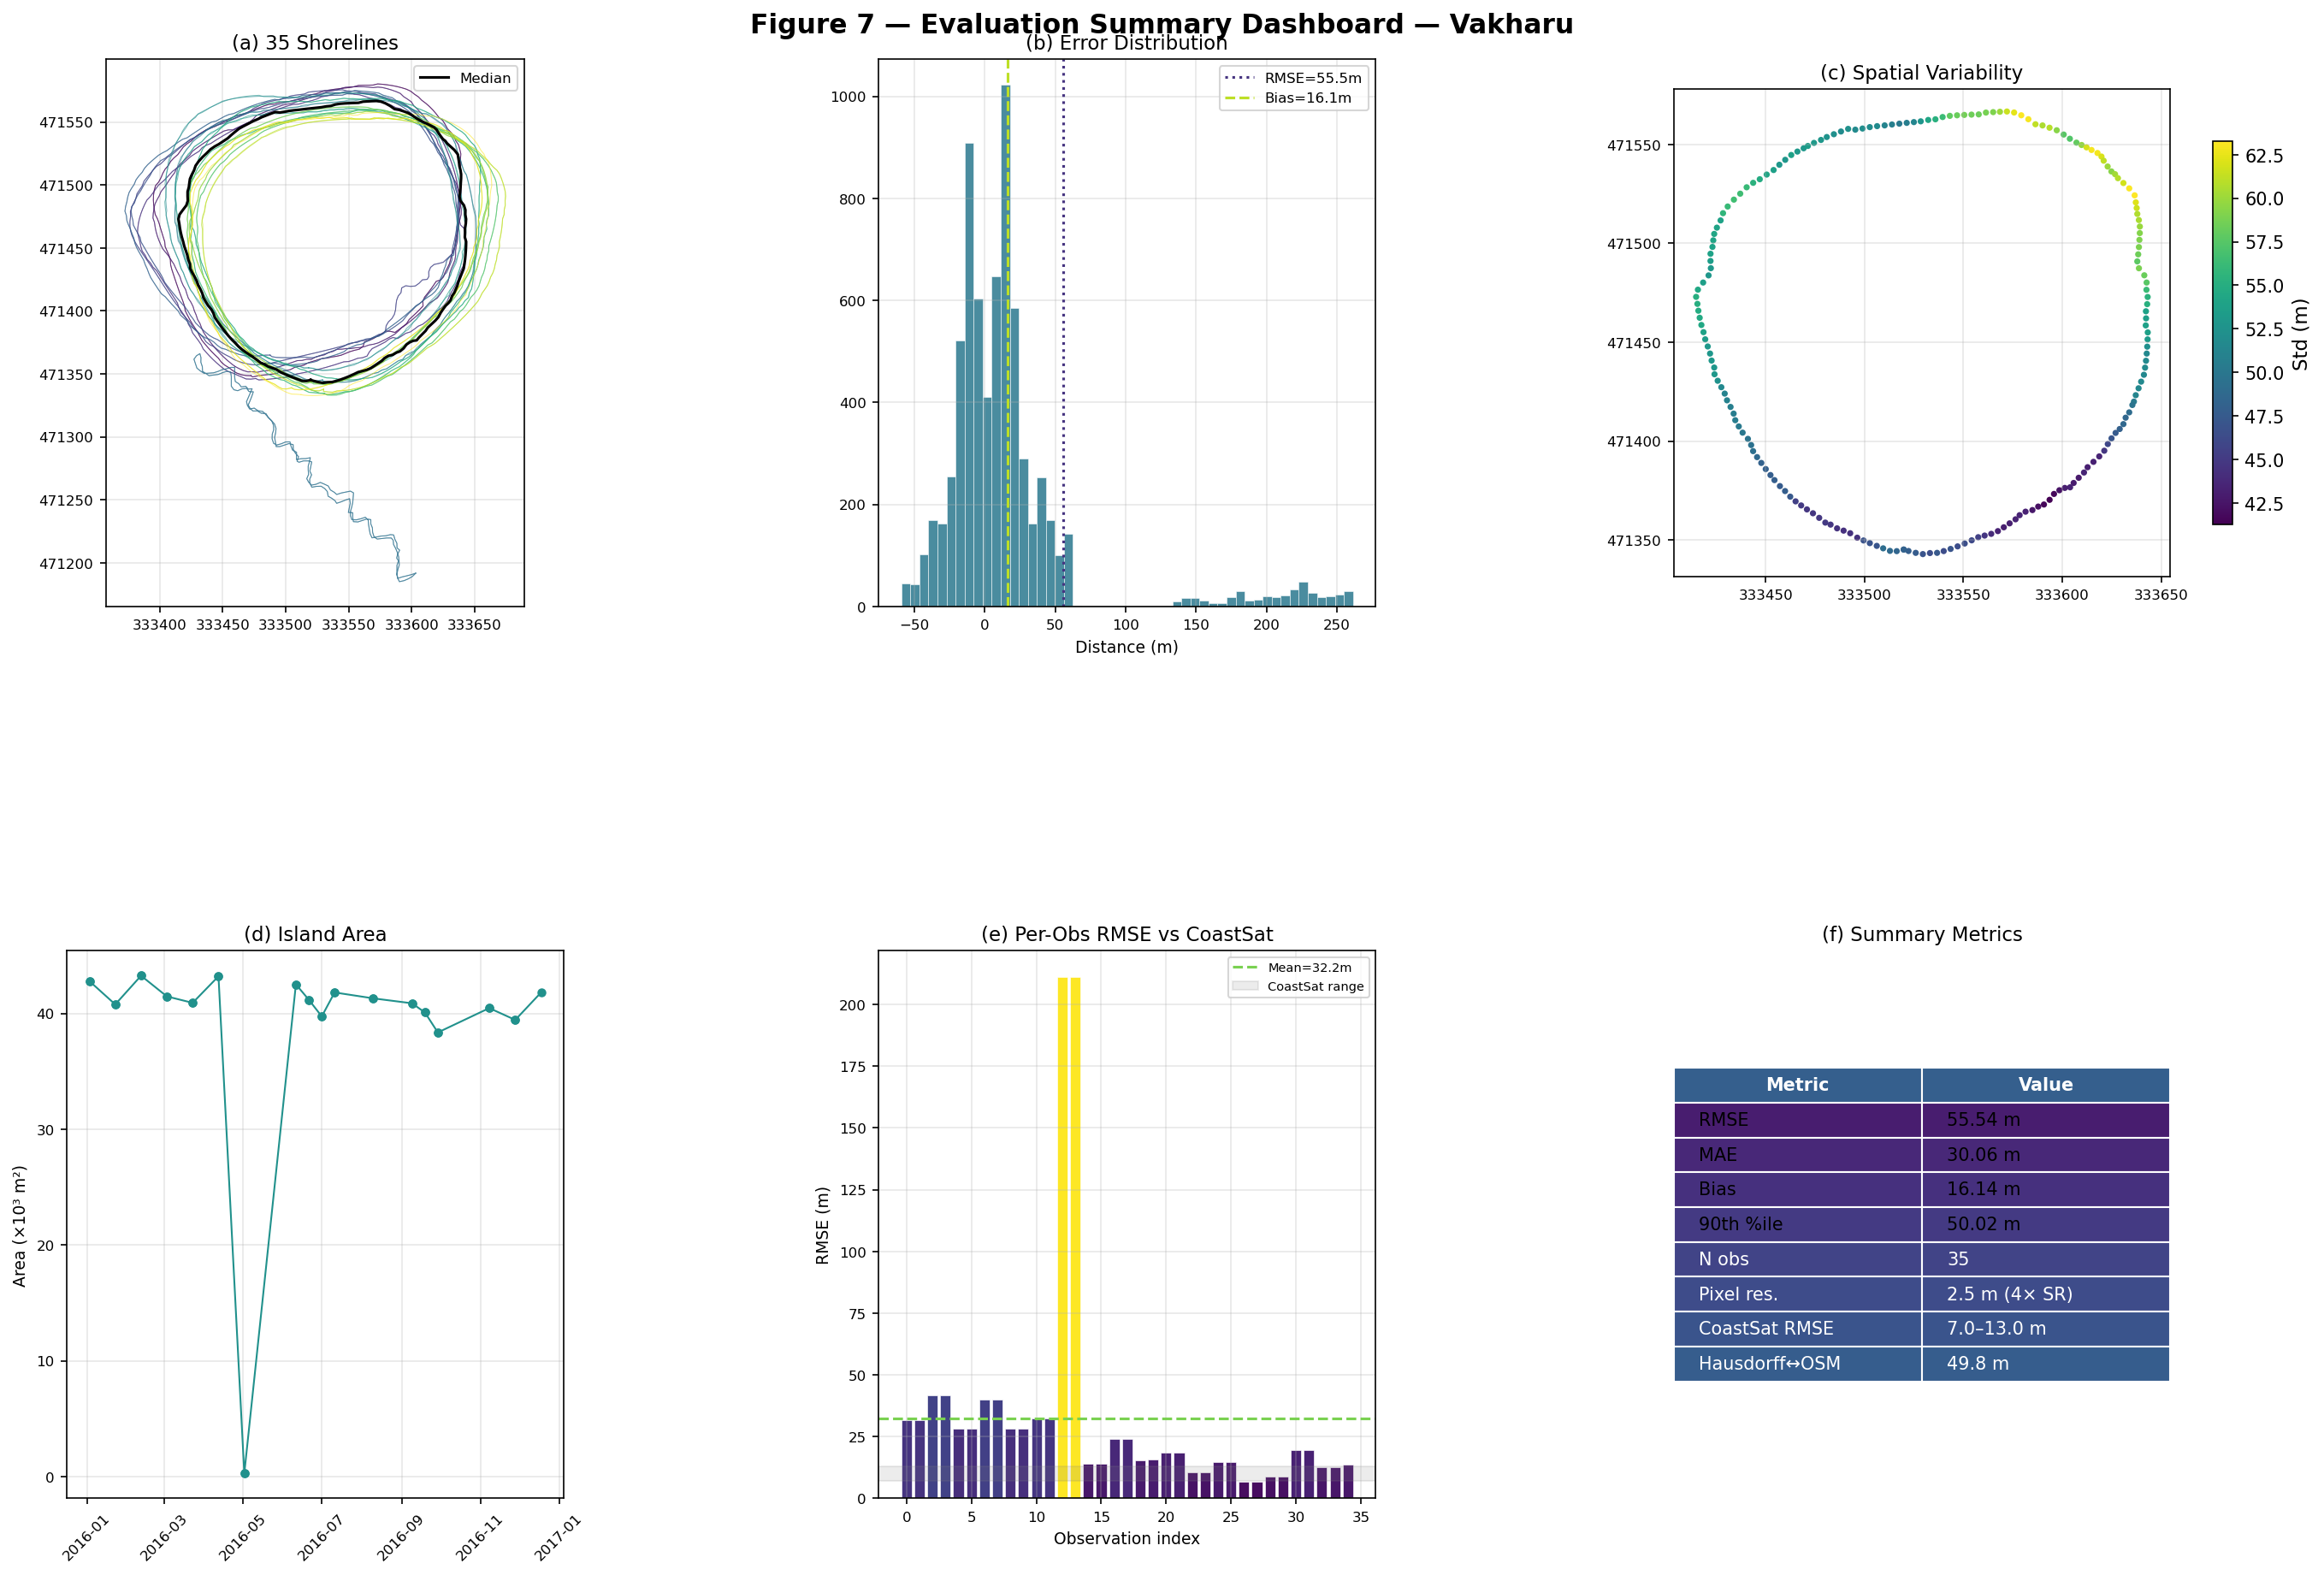

In [22]:
# ---------------------------------------------------------------------------
# Figure 7: Summary Dashboard (2×3 grid)
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Panel (a): All shorelines plan view
ax = fig.add_subplot(gs[0, 0])
for i, line in enumerate(shorelines_utm):
    xs, ys = zip(*line.coords)
    ax.plot(xs, ys, color=plt.cm.viridis(i / max(1, n_lines - 1)),
            linewidth=0.5, alpha=0.6)
mx, my = zip(*median_shoreline.coords)
ax.plot(mx, my, "k-", linewidth=1.5, label="Median")
ax.set_aspect("equal")
ax.set_title(f"(a) {n_lines} Shorelines", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.tick_params(labelsize=8)

# Panel (b): Error histogram
ax = fig.add_subplot(gs[0, 1])
ax.hist(flat_distances, bins=50, color=plt.cm.viridis(0.4),
        edgecolor="white", linewidth=0.3, alpha=0.85)
ax.axvline(metrics["RMSE (m)"], color=plt.cm.viridis(0.15),
           linestyle=":", linewidth=1.5, label=f"RMSE={metrics['RMSE (m)']:.1f}m")
ax.axvline(metrics["Bias / Mean Error (m)"], color=plt.cm.viridis(0.9),
           linestyle="--", linewidth=1.5, label=f"Bias={metrics['Bias / Mean Error (m)']:.1f}m")
ax.set_title("(b) Error Distribution", fontsize=11)
ax.set_xlabel("Distance (m)", fontsize=9)
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)

# Panel (c): Spatial variability
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(median_pts[:, 0], median_pts[:, 1],
                c=point_std, cmap="viridis", s=12, edgecolors="none")
ax.set_aspect("equal")
ax.set_title("(c) Spatial Variability", fontsize=11)
plt.colorbar(sc, ax=ax, label="Std (m)", shrink=0.7)
ax.tick_params(labelsize=8)

# Panel (d): Area time series
ax = fig.add_subplot(gs[1, 0])
valid_area = shorelines_df.dropna(subset=["area_m2"])
ax.plot(valid_area["date"], valid_area["area_m2"] / 1e3, "o-",
        color=plt.cm.viridis(0.5), markersize=4, linewidth=1)
ax.set_title("(d) Island Area", fontsize=11)
ax.set_ylabel("Area (×10³ m²)", fontsize=9)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)

# Panel (e): Per-observation RMSE
ax = fig.add_subplot(gs[1, 1])
ax.bar(range(len(per_shoreline_rmse)), per_shoreline_rmse,
       color=[plt.cm.viridis(v / per_shoreline_rmse.max()) for v in per_shoreline_rmse],
       edgecolor="white", linewidth=0.3)
ax.axhline(np.mean(per_shoreline_rmse), color=plt.cm.viridis(0.8),
           linestyle="--", label=f"Mean={np.mean(per_shoreline_rmse):.1f}m")
cs_lo, cs_hi = CONFIG["coastsat_rmse_range"]
ax.axhspan(cs_lo, cs_hi, alpha=0.15, color="grey",
           label=f"CoastSat range")
ax.set_title("(e) Per-Obs RMSE vs CoastSat", fontsize=11)
ax.set_ylabel("RMSE (m)", fontsize=9)
ax.set_xlabel("Observation index", fontsize=9)
ax.legend(fontsize=7, loc="upper right")
ax.tick_params(labelsize=8)

# Panel (f): Metrics table
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
table_data = [
    ["RMSE", f"{metrics['RMSE (m)']:.2f} m"],
    ["MAE", f"{metrics['MAE (m)']:.2f} m"],
    ["Bias", f"{metrics['Bias / Mean Error (m)']:.2f} m"],
    ["90th %ile", f"{metrics['90th Percentile Error (m)']:.2f} m"],
    ["N obs", f"{int(metrics['N observations'])}"],
    ["Pixel res.", f"{CONFIG['effective_resolution_m']:.1f} m (4× SR)"],
    ["CoastSat RMSE", f"{cs_lo}–{cs_hi} m"],
]
if hausdorff_to_ref:
    table_data.append(["Hausdorff↔OSM", f"{np.mean(hausdorff_to_ref):.1f} m"])

table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(plt.cm.viridis(0.3))
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(plt.cm.viridis(0.05 + 0.03 * row))
        cell.set_text_props(color="white" if row > 4 else "black")
    cell.set_edgecolor("white")
ax.set_title("(f) Summary Metrics", fontsize=11)

plt.suptitle(f"Figure 7 — Evaluation Summary Dashboard — {CONFIG['site_name']}",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig(CONFIG["output_dir"] / "fig7_summary_dashboard.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 16. Export Results

Save all computed metrics and per-shoreline statistics to CSV for inclusion in the manuscript and supplementary materials.

In [ ]:
# ---------------------------------------------------------------------------
# Export evaluation results
# ---------------------------------------------------------------------------
out_dir = CONFIG["output_dir"]

# 1. Summary metrics
metrics_df.to_csv(out_dir / "evaluation_metrics.csv", index=False)
print(f"Saved: {out_dir / 'evaluation_metrics.csv'}")

# 2. Per-shoreline statistics
export_cols = ["file", "date", "n_coords", "length_m", "area_m2",
               "mean_cross_dist_m", "std_cross_dist_m", "max_cross_dist_m"]
if "hausdorff_to_ref_m" in shorelines_df.columns:
    export_cols.append("hausdorff_to_ref_m")
shorelines_export = shorelines_df[export_cols].copy()
shorelines_export["per_obs_rmse_m"] = per_shoreline_rmse
shorelines_export.to_csv(out_dir / "per_shoreline_statistics.csv", index=False)
print(f"Saved: {out_dir / 'per_shoreline_statistics.csv'}")

# 3. Sector analysis
sector_summary.to_csv(out_dir / "azimuthal_sector_analysis.csv", index=False)
print(f"Saved: {out_dir / 'azimuthal_sector_analysis.csv'}")

# 4. Cross-shore distance matrix
dist_df = pd.DataFrame(
    distance_matrix,
    index=shorelines_df["date"].dt.strftime("%Y-%m-%d"),
    columns=[f"pt_{i:03d}" for i in range(N)]
)
dist_df.to_csv(out_dir / "cross_shore_distances.csv")
print(f"Saved: {out_dir / 'cross_shore_distances.csv'}")

print(f"\n{'=' * 50}")
print(f"All outputs saved to: {out_dir}")
print(f"Figures: fig1–fig7 (PNG, 300 dpi)")
print(f"Tables:  4 CSV files")
print(f"{'=' * 50}")